In [1]:
# ================================================================
#  EDA — ANÁLISIS EXPLORATORIO DE DATOS
#  Dataset: dataset_ganancia_por_venta
#  Objetivo: entender la data antes de entrenar el modelo
# ================================================================

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [165]:
df = pd.read_csv('/content/dataset_ganancia_por_venta (5).csv')
df

,sale_id,ganancia_total,n_productos,categoria_principal,n_categorias,precio_promedio,genero_principal,marca_principal,catalog_price_prom,desc_promedio,...,country,en_campana,campana_activa,age_range,mes,dia_semana,es_fin_semana,sale_date,costo_promedio,margen_pct
0,2,168.24,3,T-Shirts,3,36.656667,Female,Tiva,36.656667,0.0,...,Germany,1,Mid-Season Clearance,36-45,5,4,0,2025-05-16,20.746667,0.4340
1,3,117.27,3,Pants,3,41.606667,Female,Tiva,41.606667,0.0,...,Germany,0,Sin campaña,16-25,4,1,0,2025-04-22,27.233333,0.3455
2,6,163.22,3,T-Shirts,2,52.280000,Female,Tiva,52.280000,0.0,...,Portugal,1,Early Summer Deals,46-55,6,5,1,2025-06-14,31.076667,0.4056
3,8,198.20,3,Sleepwear,3,45.870000,Female,Tiva,45.870000,0.0,...,Italy,1,TIVA Week,16-25,5,0,0,2025-05-26,24.793333,0.4595
4,10,133.05,3,Shoes,2,52.030000,Female,Tiva,52.030000,0.0,...,France,1,TIVA Week,56-65,5,2,0,2025-05-21,29.756667,0.4281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,1343,153.71,2,Shoes,2,49.740000,Female,Tiva,49.740000,0.0,...,Netherlands,1,TIVA Week,36-45,5,2,0,2025-05-28,28.420000,0.4286
901,1344,95.27,2,T-Shirts,1,51.385000,Female,Tiva,51.385000,0.0,...,Germany,0,Sin campaña,36-45,4,0,0,2025-04-21,25.850000,0.4969
902,1348,205.30,2,T-Shirts,2,62.605000,Female,Tiva,62.605000,0.0,...,France,1,TIVA Week,16-25,5,1,0,2025-05-20,33.600000,0.4633
903,1349,73.11,2,Shoes,2,33.705000,Female,Tiva,33.705000,0.0,...,Netherlands,1,TIVA Week,46-55,5,1,0,2025-05-27,19.555000,0.4198


In [166]:
df.columns

Index(['sale_id', 'ganancia_total', 'n_productos', 'categoria_principal',
       'n_categorias', 'precio_promedio', 'genero_principal',
       'marca_principal', 'catalog_price_prom', 'desc_promedio', 'desc_maximo',
       'hubo_descuento', 'tramo_descuento', 'channel', 'country', 'en_campana',
       'campana_activa', 'age_range', 'mes', 'dia_semana', 'es_fin_semana',
       'sale_date', 'costo_promedio', 'margen_pct'],
      dtype='object')

EDA

In [167]:
# ================================================================
# BLOQUE 1 — RESUMEN GENERAL
# ================================================================

print("SHAPE:", df.shape)
print("\nTIPOS Y NULOS:")
print(df.info())
print("\nESTADÍSTICAS NUMÉRICAS:")
print(df.describe().round(2))
print("\nESTADÍSTICAS CATEGÓRICAS:")
print(df.describe(include='object'))

SHAPE: (905, 24)

TIPOS Y NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sale_id              905 non-null    int64  
 1   ganancia_total       905 non-null    float64
 2   n_productos          905 non-null    int64  
 3   categoria_principal  905 non-null    object 
 4   n_categorias         905 non-null    int64  
 5   precio_promedio      905 non-null    float64
 6   genero_principal     905 non-null    object 
 7   marca_principal      905 non-null    object 
 8   catalog_price_prom   905 non-null    float64
 9   desc_promedio        905 non-null    float64
 10  desc_maximo          905 non-null    float64
 11  hubo_descuento       905 non-null    int64  
 12  tramo_descuento      905 non-null    object 
 13  channel              905 non-null    object 
 14  country              905 non-null    object 
 15  en_camp

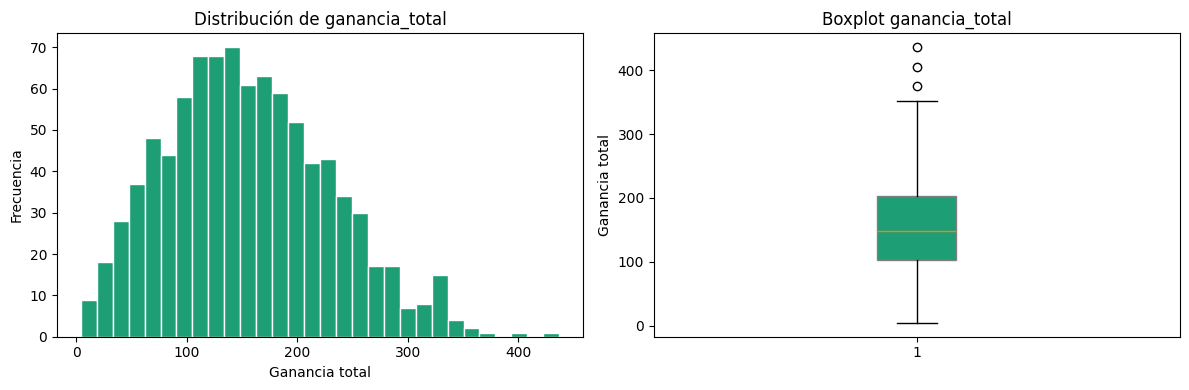

In [168]:
# ================================================================
# BLOQUE 2 — DISTRIBUCIÓN DEL TARGET (ganancia_total)
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df['ganancia_total'], bins=30, color='#1D9E75', edgecolor='white')
axes[0].set_title('Distribución de ganancia_total')
axes[0].set_xlabel('Ganancia total')
axes[0].set_ylabel('Frecuencia')

# Boxplot para detectar outliers
axes[1].boxplot(df['ganancia_total'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#1D9E75', color='gray'))
axes[1].set_title('Boxplot ganancia_total')
axes[1].set_ylabel('Ganancia total')

plt.tight_layout()
plt.show()


In [169]:
# ================================================================
# TRATAMIENTO DE OUTLIERS EN ganancia_total
# ================================================================

Q1 = df['ganancia_total'].quantile(0.25)
Q3 = df['ganancia_total'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['ganancia_total'] < limite_inferior) | (df['ganancia_total'] > limite_superior)]
print(f"Outliers detectados: {len(outliers)} filas ({len(outliers)/len(df)*100:.1f}%)")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")

df_clean = df[(df['ganancia_total'] >= limite_inferior) & (df['ganancia_total'] <= limite_superior)].copy()
print(f"\nDataset original: {len(df)} filas")
print(f"Dataset limpio:   {len(df_clean)} filas")

Outliers detectados: 3 filas (0.3%)
Límite inferior: -49.90
Límite superior: 356.07

Dataset original: 905 filas
Dataset limpio:   902 filas


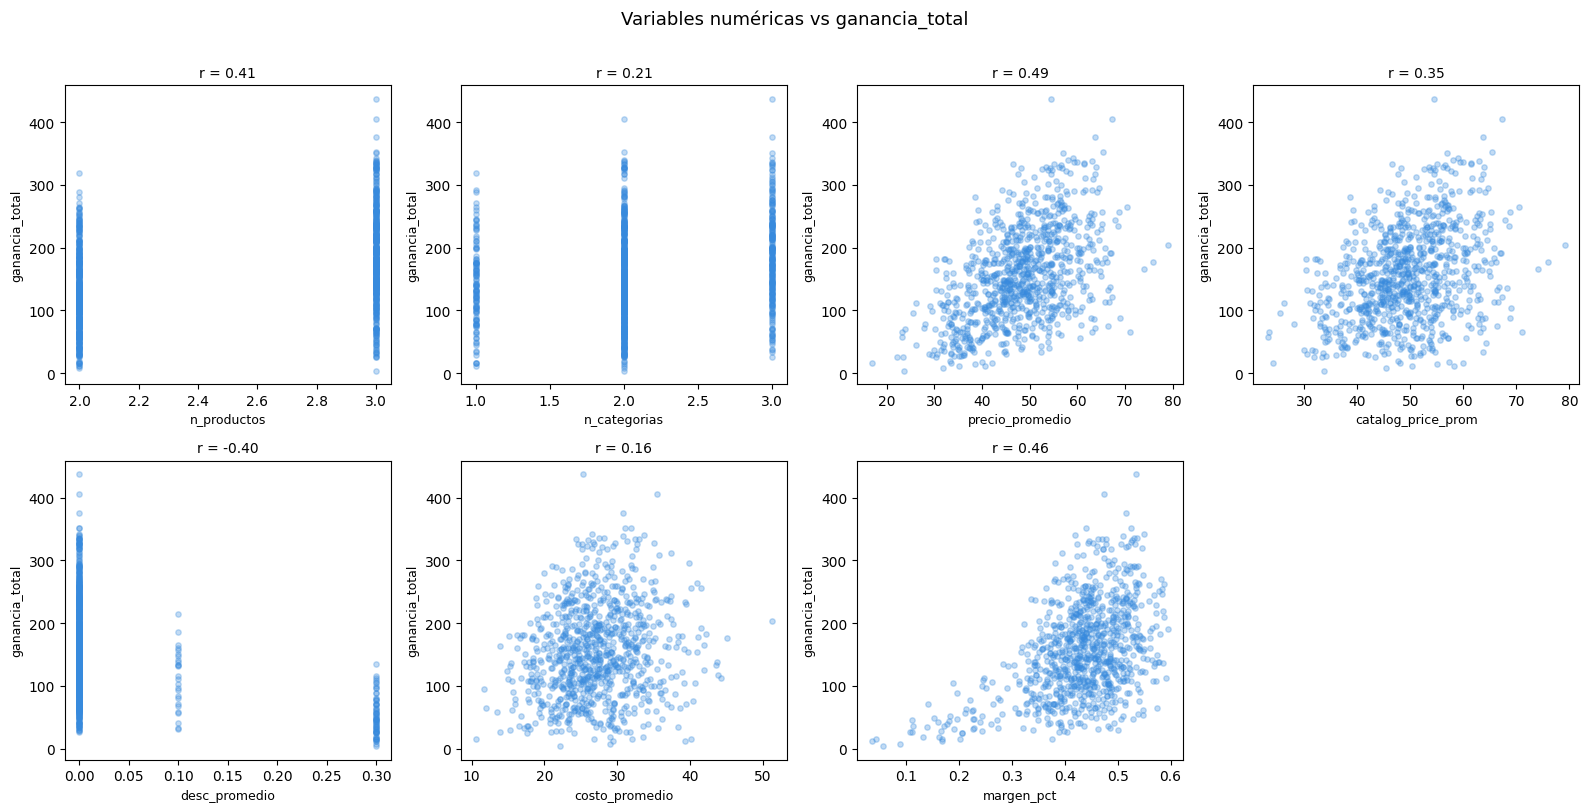

In [170]:
# ================================================================
# BLOQUE 3 — VARIABLES NUMÉRICAS vs TARGET
# ================================================================

cols_num = ['n_productos', 'n_categorias', 'precio_promedio',
            'catalog_price_prom', 'desc_promedio', 'costo_promedio', 'margen_pct']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].scatter(df[col], df['ganancia_total'], alpha=0.3, s=15, color='#378ADD')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('ganancia_total', fontsize=9)
    r = df[col].corr(df['ganancia_total'])
    axes[i].set_title(f'r = {r:.2f}', fontsize=10)

axes[-1].axis('off')
plt.suptitle('Variables numéricas vs ganancia_total', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

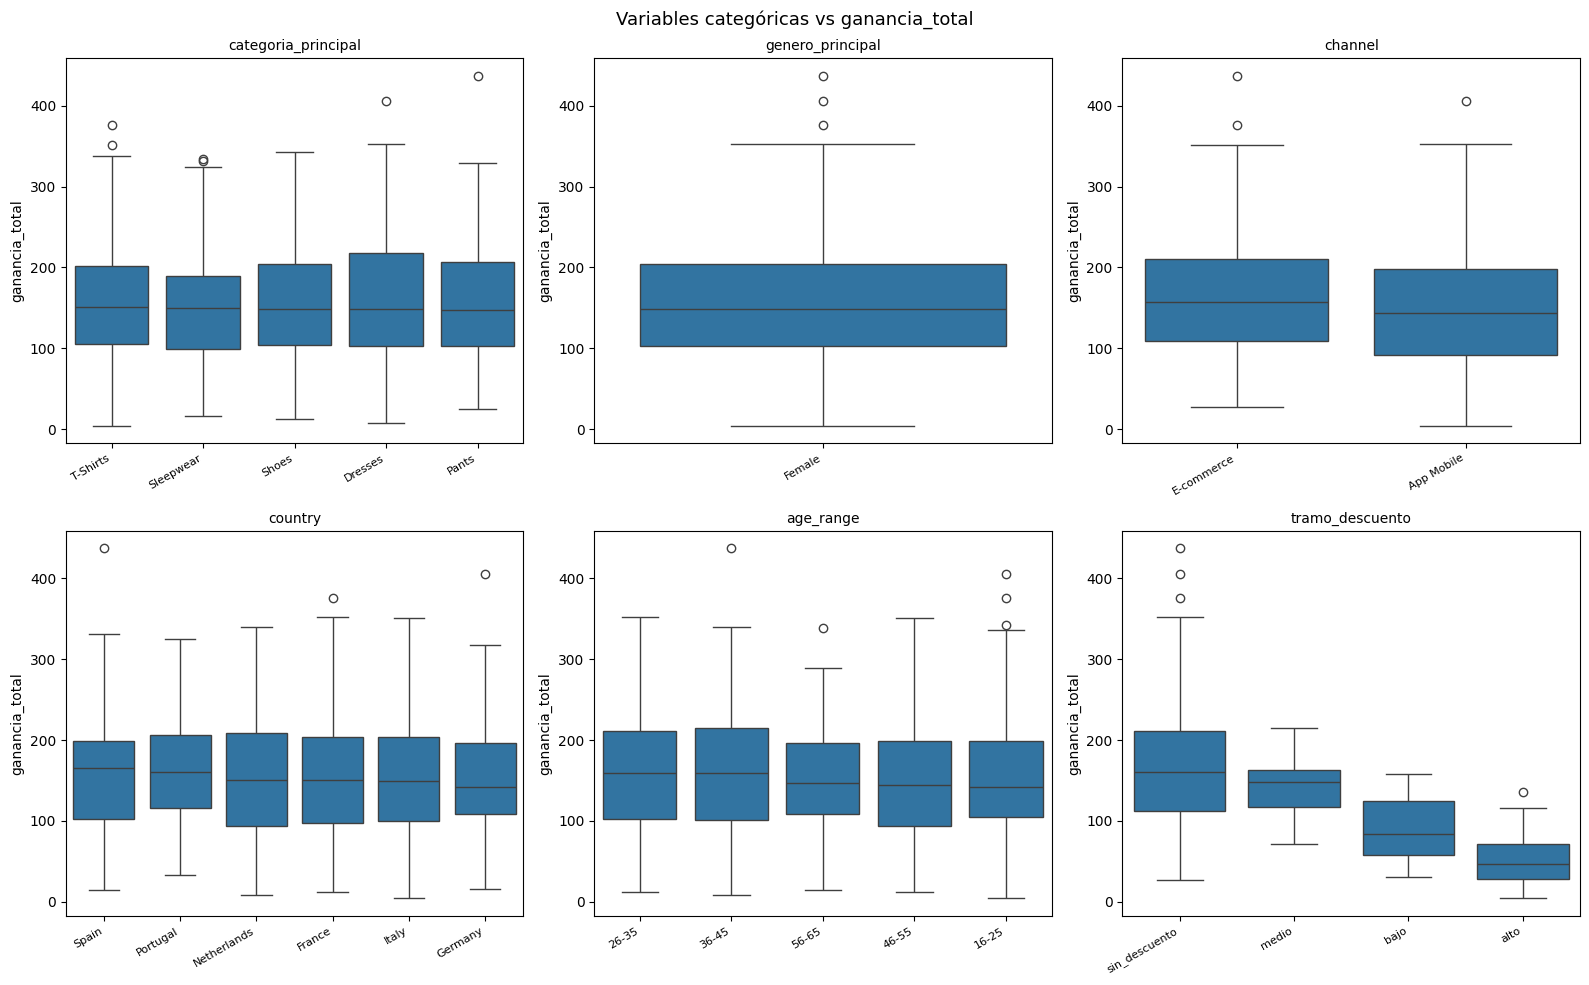

In [171]:
# ================================================================
# BLOQUE 4 — VARIABLES CATEGÓRICAS vs TARGET
# ================================================================

cols_cat = ['categoria_principal', 'genero_principal', 'channel',
            'country', 'age_range', 'tramo_descuento']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    orden = df.groupby(col)['ganancia_total'].median().sort_values(ascending=False).index
    sns.boxplot(x=col, y='ganancia_total', data=df, ax=axes[i],
               order=orden, patch_artist=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    plt.sca(axes[i])
    plt.xticks(rotation=30, ha='right', fontsize=8)

plt.suptitle('Variables categóricas vs ganancia_total', fontsize=13)
plt.tight_layout()
plt.show()

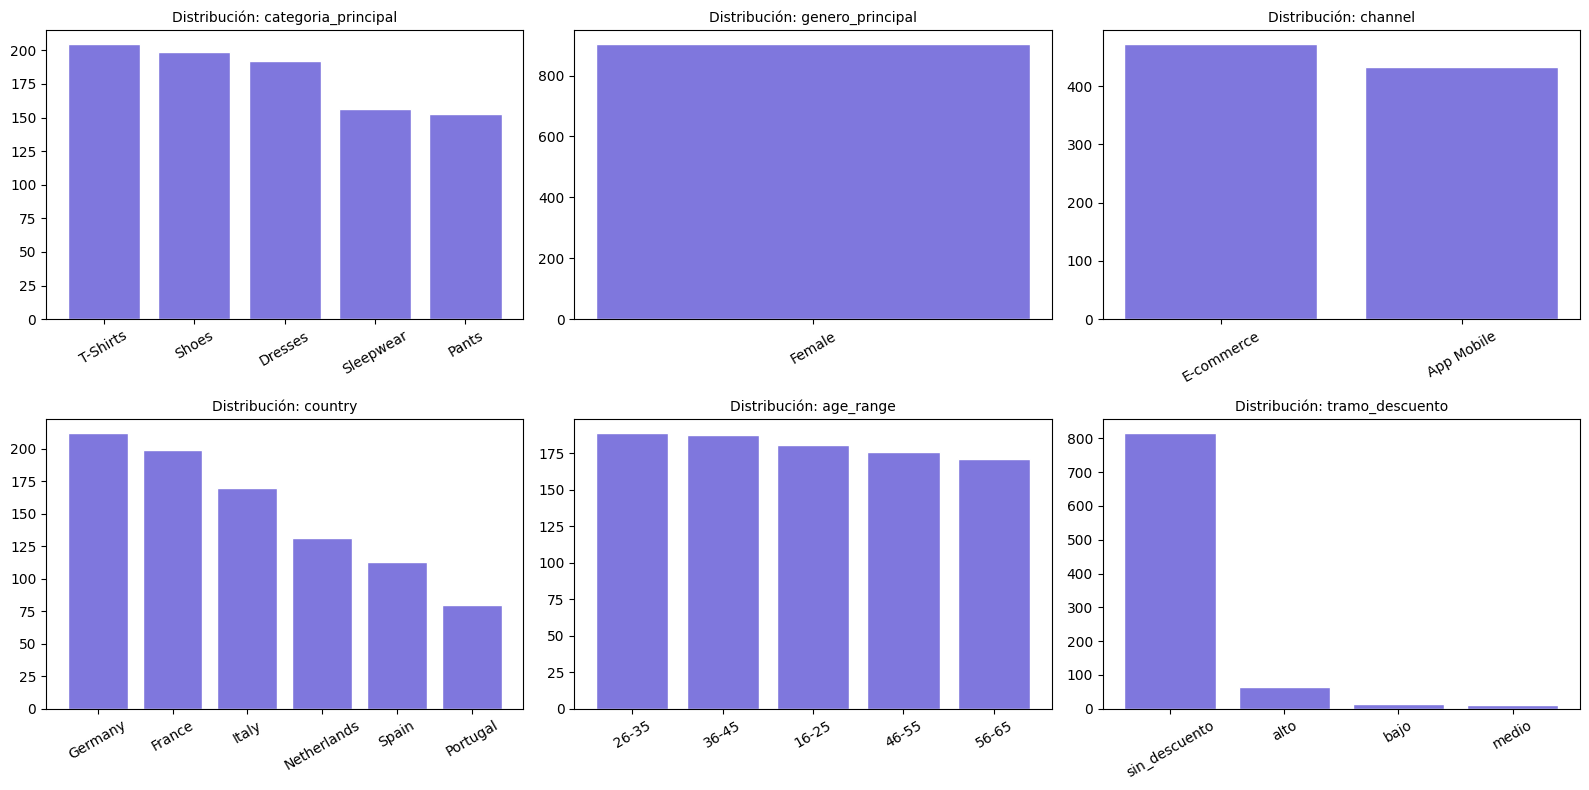

In [172]:
# ================================================================
# BLOQUE 5 — DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS (frecuencias)
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='#7F77DD', edgecolor='white')
    axes[i].set_title(f'Distribución: {col}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

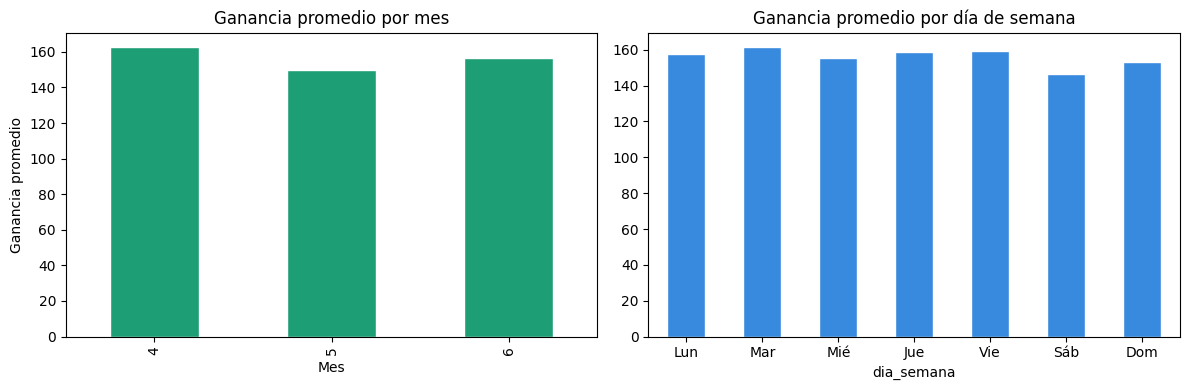

In [173]:
# ================================================================
# BLOQUE 6 — GANANCIA POR MES Y DÍA DE SEMANA
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('mes')['ganancia_total'].mean().plot(
    kind='bar', ax=axes[0], color='#1D9E75', edgecolor='white')
axes[0].set_title('Ganancia promedio por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ganancia promedio')

dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
df.groupby('dia_semana')['ganancia_total'].mean().plot(
    kind='bar', ax=axes[1], color='#378ADD', edgecolor='white')
axes[1].set_title('Ganancia promedio por día de semana')
axes[1].set_xticklabels(dias, rotation=0)

plt.tight_layout()
plt.show()


#

--- Correlación con ganancia_total ---
ganancia_total        1.000000
precio_promedio       0.491882
margen_pct            0.455788
n_productos           0.413170
catalog_price_prom    0.352424
n_categorias          0.206771
costo_promedio        0.158174
dia_semana           -0.040537
mes                  -0.049048
es_fin_semana        -0.055691
en_campana           -0.064288
hubo_descuento       -0.381309
sale_id              -0.382695
desc_promedio        -0.396062
desc_maximo          -0.396062
Name: ganancia_total, dtype: float64


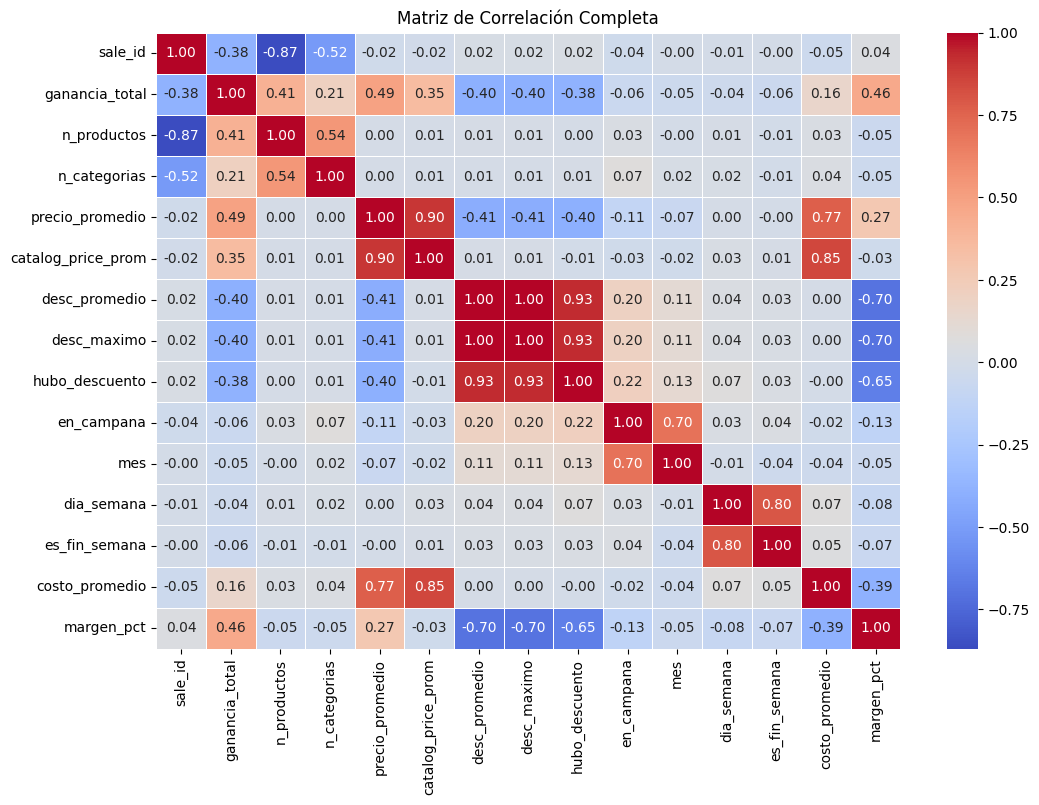

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar solo las columnas numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# 2. Calcular la correlación con el target
correlacion_target = df_numerico.corr()['ganancia_total'].sort_values(ascending=False)

print("--- Correlación con ganancia_total ---")
print(correlacion_target)

# 3. Graficar un mapa de calor (Heatmap) de las variables numéricas
plt.figure(figsize=(12, 8))
sns.heatmap(df_numerico.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación Completa')
plt.show()

descuento promedio ydesucneot maximo son lo mismo

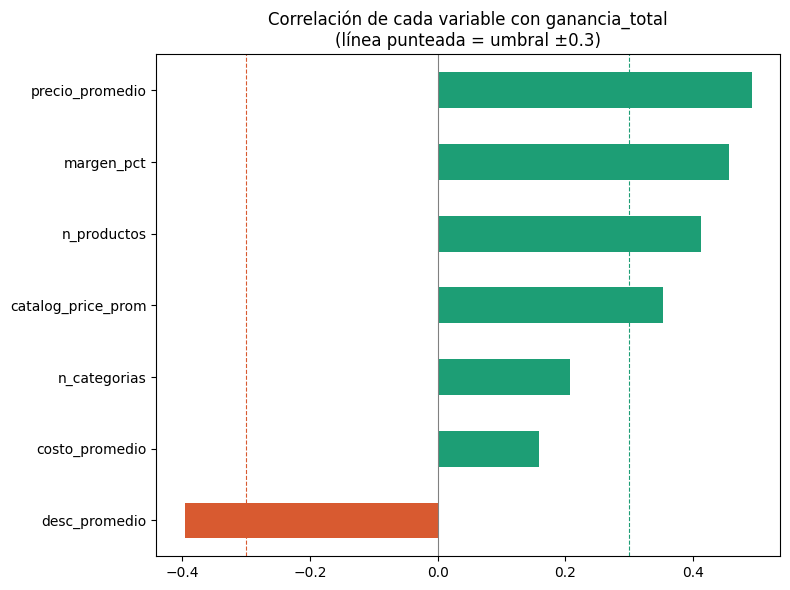

desc_promedio        -0.396
costo_promedio        0.158
n_categorias          0.207
catalog_price_prom    0.352
n_productos           0.413
margen_pct            0.456
precio_promedio       0.492
Name: ganancia_total, dtype: float64


In [175]:
# ================================================================
# 1 — CORRELACIÓN CON EL TARGET
# ================================================================

corr_target = df[cols_num + ['ganancia_total']].corr()['ganancia_total'].drop('ganancia_total').sort_values()

plt.figure(figsize=(8, 6))
colores = ['#D85A30' if v < 0 else '#1D9E75' for v in corr_target]
corr_target.plot(kind='barh', color=colores)
plt.axvline(0, color='gray', linewidth=0.8)
plt.axvline(0.3,  color='#1D9E75', linestyle='--', linewidth=0.8)
plt.axvline(-0.3, color='#D85A30', linestyle='--', linewidth=0.8)
plt.title('Correlación de cada variable con ganancia_total\n(línea punteada = umbral ±0.3)')
plt.tight_layout()
plt.show()

print(corr_target.round(3))

SON SOLO 7 PORQUE TENGO SOLO 7 NUMERICAS

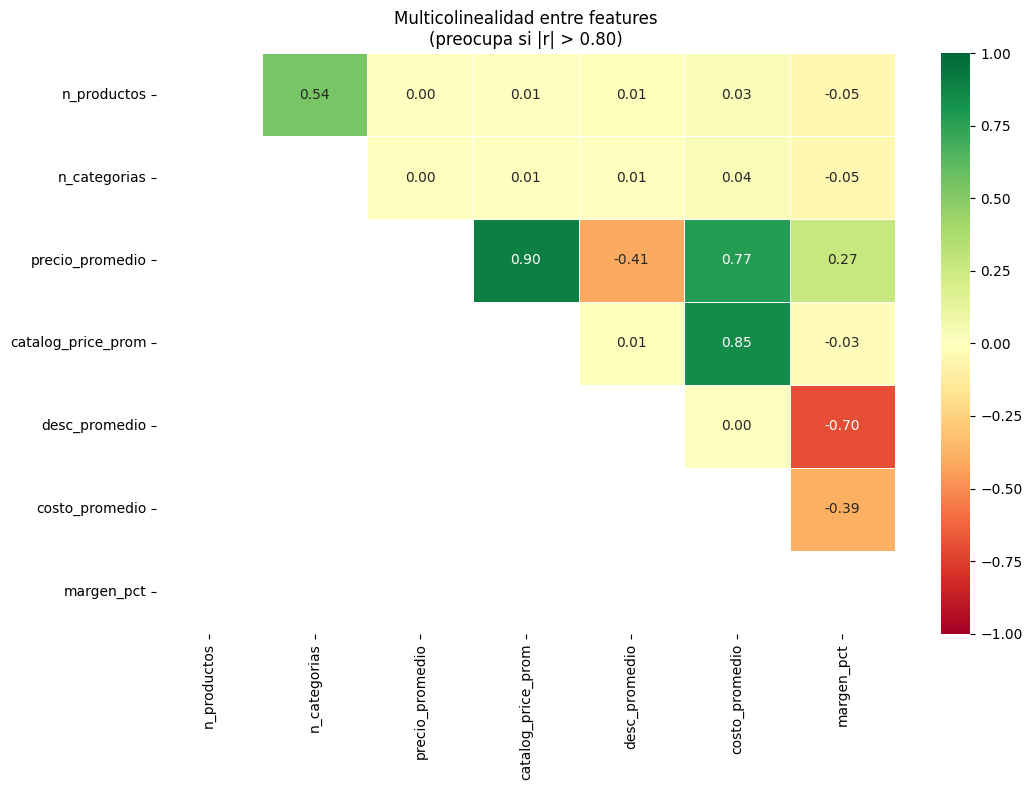

In [176]:
# ================================================================
# 2 — MULTICOLINEALIDAD (heatmap entre features)
# ================================================================

corr_matrix = df[cols_num].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            mask=pd.DataFrame(corr_matrix).where(
                np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).isna())
plt.title('Multicolinealidad entre features\n(preocupa si |r| > 0.80)')
plt.tight_layout()
plt.show()

#FEACTURE ENGINEERING

In [178]:
# ================================================================
# FEATURE ENGINEERING
# ================================================================

# 1. Ingreso bruto (precio total sin descuento)
df['ingreso_bruto'] = df['precio_promedio'] * df['n_productos']

# 2. Descuento absoluto (dinero real perdido por descuento)
df['descuento_absoluto'] = df['ingreso_bruto'] * df['desc_promedio']

# 3. Ingreso neto estimado (ingreso bruto menos descuento)
df['ingreso_neto_estimado'] = df['ingreso_bruto'] - df['descuento_absoluto']

# 4. Precio por categoría (perfil de compra)
df['precio_por_categoria'] = df['precio_promedio'] / df['n_categorias']

# 5. Ganancia media por mes (contexto temporal — target encoding)
ganancia_media_mes = df.groupby('mes')['ganancia_total'].transform('mean')
df['ganancia_media_mes'] = ganancia_media_mes

In [177]:
# ---------- BLOQUE 2: Variables del segundo set ----------

# 6. Intensidad del descuento (presión total del descuento sobre la venta)
df['intensidad_descuento'] = df['desc_promedio'] * df['n_productos']

# 7. Concentración de compra (productos por categoría)
df['concentracion_compra'] = df['n_productos'] / df['n_categorias']

# 8. Precio alto (señal binaria: precio sobre la mediana)
mediana_precio = df['precio_promedio'].median()
df['precio_alto'] = (df['precio_promedio'] > mediana_precio).astype(int)

# 9. Venta con descuento alto (umbral 15%)
df['venta_con_descuento_alto'] = (df['desc_promedio'] > 0.15).astype(int)

# 10. Ganancia media por categoría (target encoding de categoría)
df['ganancia_media_categoria'] = df.groupby('categoria_principal')['ganancia_total'].transform('mean')

=== Correlación con ganancia_total ===
ingreso_neto_estimado       0.678
ingreso_bruto               0.646
precio_promedio             0.492
margen_pct                  0.456
n_productos                 0.413
precio_alto                 0.396
catalog_price_prom          0.352
n_categorias                0.207
costo_promedio              0.158
precio_por_categoria        0.092
ganancia_media_mes          0.079
concentracion_compra        0.074
ganancia_media_categoria    0.045
descuento_absoluto         -0.372
venta_con_descuento_alto   -0.379
intensidad_descuento       -0.381
desc_promedio              -0.396
Name: ganancia_total, dtype: float64


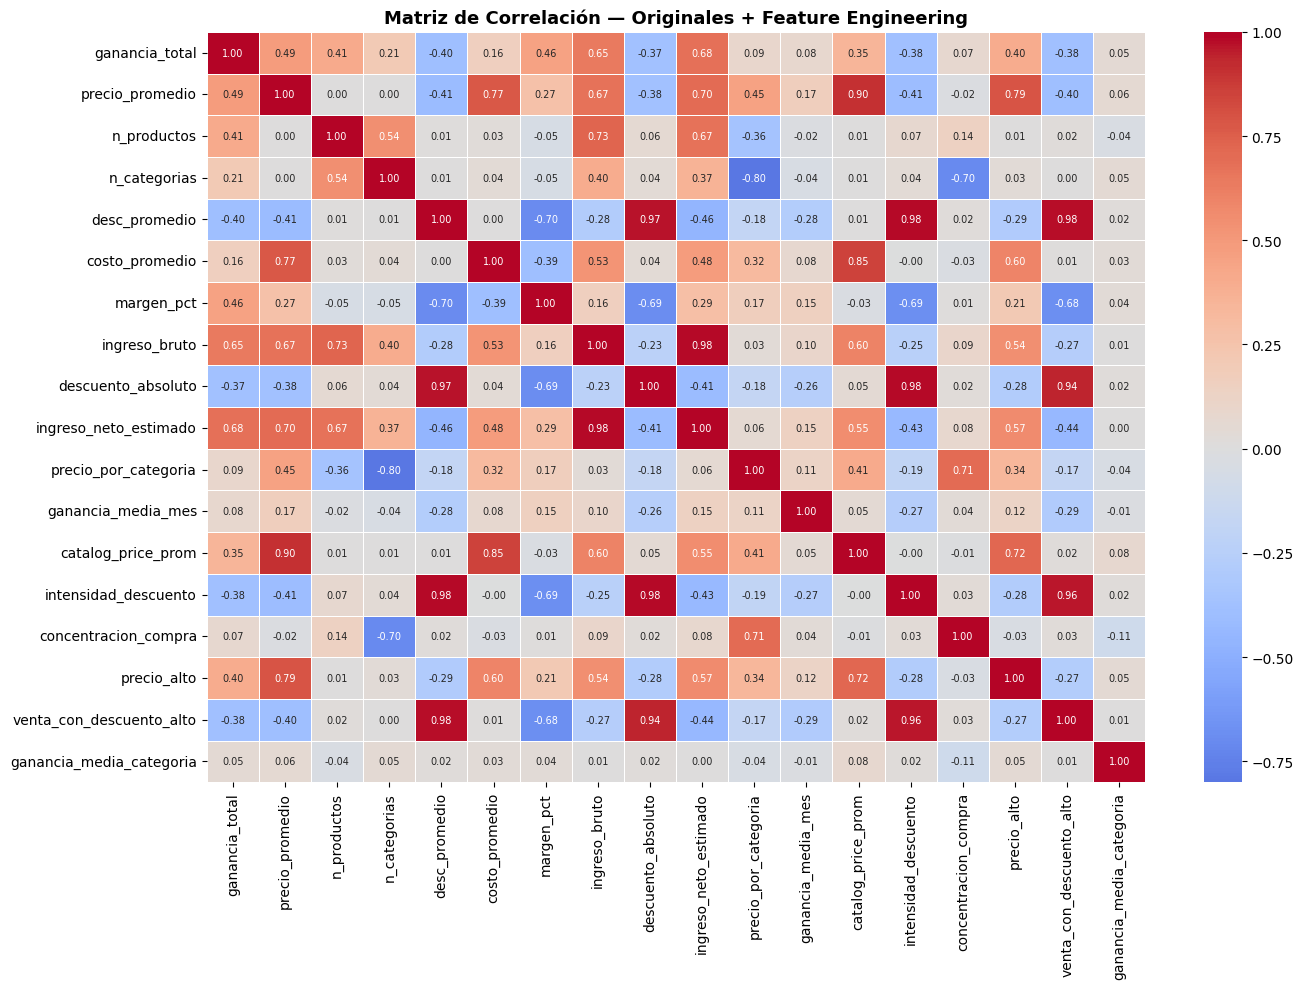

In [179]:
# ================================================================
# MATRIZ DE CORRELACIÓN — Variables originales + nuevas vs target
# ================================================================
import seaborn as sns
import matplotlib.pyplot as plt

todas_las_vars = [
    'ganancia_total',
    # Originales
    'precio_promedio', 'n_productos','n_categorias',
    'desc_promedio', 'costo_promedio', 'margen_pct',

    # Nuevas bloque 1
    'ingreso_bruto', 'descuento_absoluto', 'ingreso_neto_estimado',
    'precio_por_categoria', 'ganancia_media_mes','catalog_price_prom',
    # Nuevas bloque 2
    'intensidad_descuento', 'concentracion_compra',
    'precio_alto', 'venta_con_descuento_alto', 'ganancia_media_categoria'
]

corr = df[todas_las_vars].corr()

# --- Correlación con el target ordenada ---
print("=== Correlación con ganancia_total ===")
print(corr['ganancia_total'].drop('ganancia_total').sort_values(ascending=False).round(3))

# --- Heatmap ---
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Matriz de Correlación — Originales + Feature Engineering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

eliminaremos porq no aportan NADA


*   ganancia_media_Categorica
*   ganancia_media_mes
*   n_categorias
*   costo_promedio
*   precio_por_categoria
*   concentracion_compra







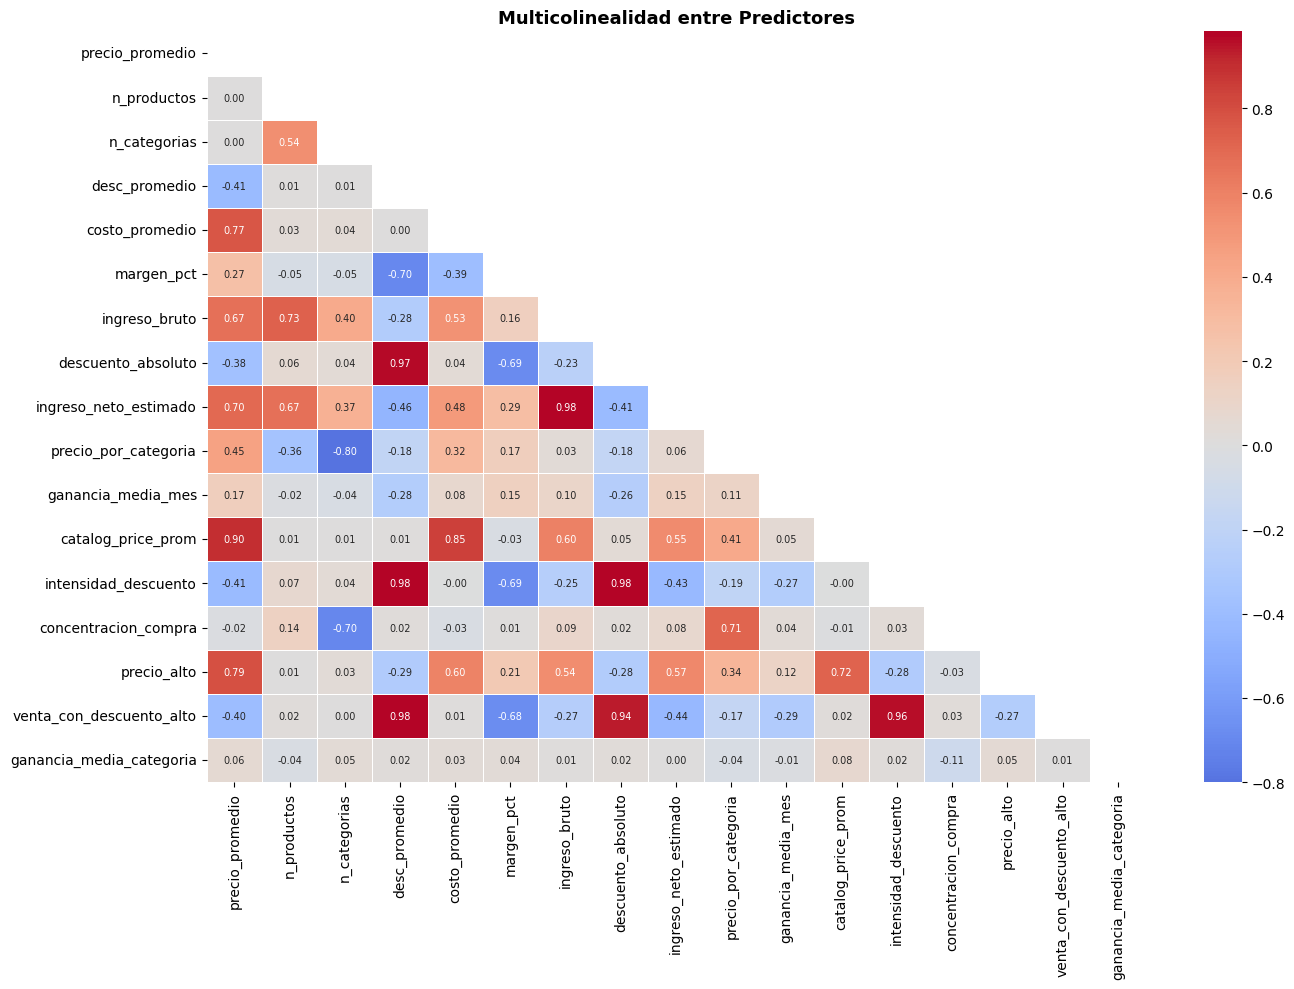


=== Pares con alta multicolinealidad (|r| > 0.80) ===
          Variable A               Variable B  Correlación
  descuento_absoluto     intensidad_descuento        0.983
       ingreso_bruto    ingreso_neto_estimado        0.981
       desc_promedio     intensidad_descuento        0.979
       desc_promedio venta_con_descuento_alto        0.976
       desc_promedio       descuento_absoluto        0.969
intensidad_descuento venta_con_descuento_alto        0.958
  descuento_absoluto venta_con_descuento_alto        0.939
     precio_promedio       catalog_price_prom        0.904
      costo_promedio       catalog_price_prom        0.851
        n_categorias     precio_por_categoria       -0.800


In [180]:
# ================================================================
# MULTICOLINEALIDAD — Solo entre predictores (sin el target)
# ================================================================

predictores = [v for v in todas_las_vars if v != 'ganancia_total']
corr_pred = df[predictores].corr()

# --- Heatmap multicolinealidad ---
mask = np.triu(np.ones_like(corr_pred, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_pred, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, annot_kws={'size': 7})
plt.title('Multicolinealidad entre Predictores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Reporte automático de pares problemáticos ---
print("\n=== Pares con alta multicolinealidad (|r| > 0.80) ===")
pares = []
for i in range(len(corr_pred.columns)):
    for j in range(i+1, len(corr_pred.columns)):
        r = corr_pred.iloc[i, j]
        if abs(r) > 0.80:
            pares.append({
                'Variable A': corr_pred.columns[i],
                'Variable B': corr_pred.columns[j],
                'Correlación': round(r, 3)
            })

if pares:
    pares_df = pd.DataFrame(pares).sort_values('Correlación', key=abs, ascending=False)
    print(pares_df.to_string(index=False))
else:
    print("✅ No hay pares con multicolinealidad alta.")

Por este lado eliminaremos:

*   descuento absoluto (reemplazado por intensidad de descuento q tiene + relacion con el target)
*  ingreso_bruto (remplazada con ingreso_neto_estimado)
*  intensidad_descuento (replzada por descuento_promedio)
*  venta_con_descuento_alto (replzada por descuento_promedio)
*  n_categorias

# 1er MODELO DE REGRESIÓN LINEAL

In [181]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

In [206]:
# ---------------------------------------------------------
# PASO 1: Eliminación final de variables con multicolinealidad severa y las qno aportan nd
# ---------------------------------------------------------
# Eliminamos los duplicados
columnas_multicolineales = ['hubo_descuento', 'precio_alto', 'ganancia_media_categoria','descuento_absoluto',
                            'ingreso_bruto','intensidad_descuento','venta_con_descuento_alto','n_categorias',
                            'sale_id','en_campana','concentracion_compra', 'ganancia_media_mes','costo_promedio',
                            'campana_activa','desc_promedio','precio_por_categoria', 'sale_date',  #despromedio remplazado por margen_pct
                             'mes', 'dia_semana', 'es_fin_semana','genero_principal_enc','marca_principal_enc',
                            'genero_principal', 'catalog_price_prom','tramo_descuento', 'ingreso_neto_estimado', 'age_range','margen_pct']  #eliminando fechas y genero principal
df_final_model = df.drop(columns=columnas_multicolineales, errors='ignore')

In [207]:
# ---------------------------------------------------------
# PASO 2: Separar X (características) e y (target)
# ---------------------------------------------------------
X = df_final_model.drop(columns=['ganancia_total'])
y = df_final_model['ganancia_total']

# Identificar tipos de columnas restantes
columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
columnas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables numéricas definitivas:", columnas_numericas)
print("Variables categóricas definitivas:", columnas_categoricas)

Variables numéricas definitivas: ['n_productos', 'precio_promedio', 'desc_maximo']
Variables categóricas definitivas: ['categoria_principal', 'marca_principal', 'channel', 'country']


In [208]:
# ---------------------------------------------------------
# PASO 3: División en Entrenamiento y Prueba (Train/Test Split)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [209]:
# ---------------------------------------------------------
# PASO 4: Pipeline de Transformación (Encoding y Escalado)
# ---------------------------------------------------------
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), columnas_categoricas)
    ]
)

# Ajustamos en Train y transformamos ambos
X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)

In [210]:
# ---------------------------------------------------------
# PASO 5: Entrenamiento del Modelo
# ---------------------------------------------------------
modelo = LinearRegression()
modelo.fit(X_train_procesado, y_train)

# ---------------------------------------------------------
# PASO 6: Predicciones y Métricas de Rendimiento
# ---------------------------------------------------------
y_pred = modelo.predict(X_test_procesado)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n==========================================")
print("       MÉTRICAS DEL MODELO       ")
print("==========================================")
print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")


       MÉTRICAS DEL MODELO       
R² (Coeficiente de determinación): 0.4952
MAE (Error Absoluto Medio): 45.81
RMSE (Raíz del Error Cuadrático Medio): 56.35


In [211]:
# Cross-validation (para confiar en el resultado)
scores = cross_val_score(modelo, X_train_procesado, y_train, cv=5, scoring='r2')
print(f"\nCV R² promedio: {scores.mean():.3f} \u00b1 {scores.std():.3f}")


CV R² promedio: 0.423 ± 0.043


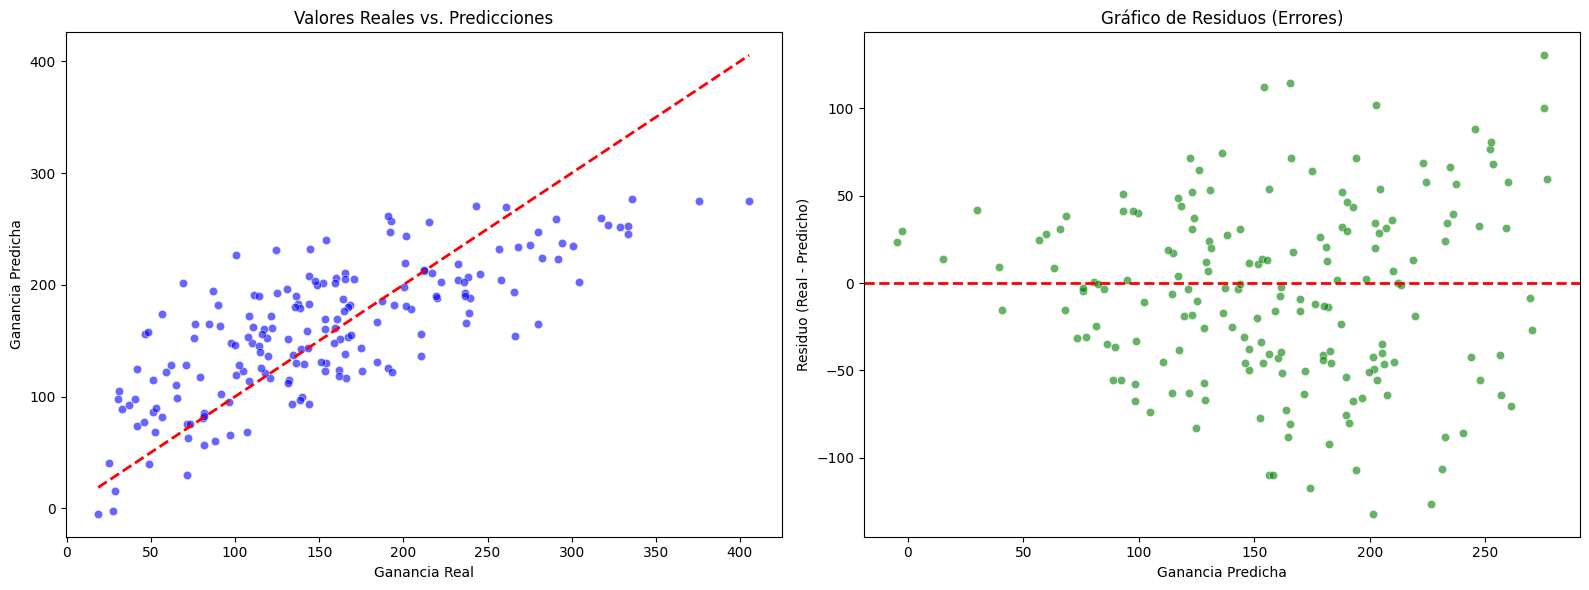

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del lienzo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Valores Reales vs Predicciones
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.6, color='b')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea ideal
axes[0].set_title('Valores Reales vs. Predicciones')
axes[0].set_xlabel('Ganancia Real')
axes[0].set_ylabel('Ganancia Predicha')

# Grafico 2: Gráfico de Residuos
residuos = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuos, ax=axes[1], alpha=0.6, color='g')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2) # Línea de error cero
axes[1].set_title('Gráfico de Residuos (Errores)')
axes[1].set_xlabel('Ganancia Predicha')
axes[1].set_ylabel('Residuo (Real - Predicho)')

plt.tight_layout()
plt.show()

# 2do MODELO DESICION TREE

In [84]:
# ================================================================
# MODELO 2 — DECISION TREE REGRESSOR
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [218]:
# ================================================================
# PASO 1 — PREPARAR VARIABLES (mismas que en regresión lineal)
# ================================================================

cols_cat = ['categoria_principal', 'marca_principal', 'channel', 'country', 'age_range']

le = LabelEncoder()
for col in cols_cat:
    if col in df.columns:
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))

features = [
    # Numéricas
    'n_productos', 'precio_promedio','desc_maximo'
    # Categóricas codificadas
    'categoria_principal_enc', 'channel_enc', 'country_enc', 'age_range_enc'
]

features = [f for f in features if f in df.columns]
print("Features:", features)

X = df[features]
y = df['ganancia_total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Features: ['n_productos', 'precio_promedio', 'channel_enc', 'country_enc', 'age_range_enc']
Train: (724, 5) | Test: (181, 5)


In [219]:
# ================================================================
# PASO 2 — MODELO BASE
# ================================================================

dt_base = DecisionTreeRegressor(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)

print("\n--- DECISION TREE BASE ---")
print(f"R²:   {r2_score(y_test, y_pred_base):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_base):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.2f}")



--- DECISION TREE BASE ---
R²:   -0.0865
MAE:  66.61
RMSE: 82.67


In [220]:
# ================================================================
# PASO 3 — TUNEO
# ================================================================

param_grid = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_leaf':  [1, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid.best_params_}")
print(f"Mejor R² en CV:     {grid.best_score_:.4f}")


Mejores parámetros: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor R² en CV:     0.3674


In [221]:
# ================================================================
# PASO 4 — MODELO TUNEADO
# ================================================================

dt_best = grid.best_estimator_
y_pred  = dt_best.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- DECISION TREE TUNEADO ---")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

cv_scores = cross_val_score(dt_best, X, y, cv=5, scoring='r2')
print(f"CV R² promedio: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


--- DECISION TREE TUNEADO ---
R²:   0.4727
MAE:  45.54
RMSE: 57.59
CV R² promedio: 0.284 ± 0.042


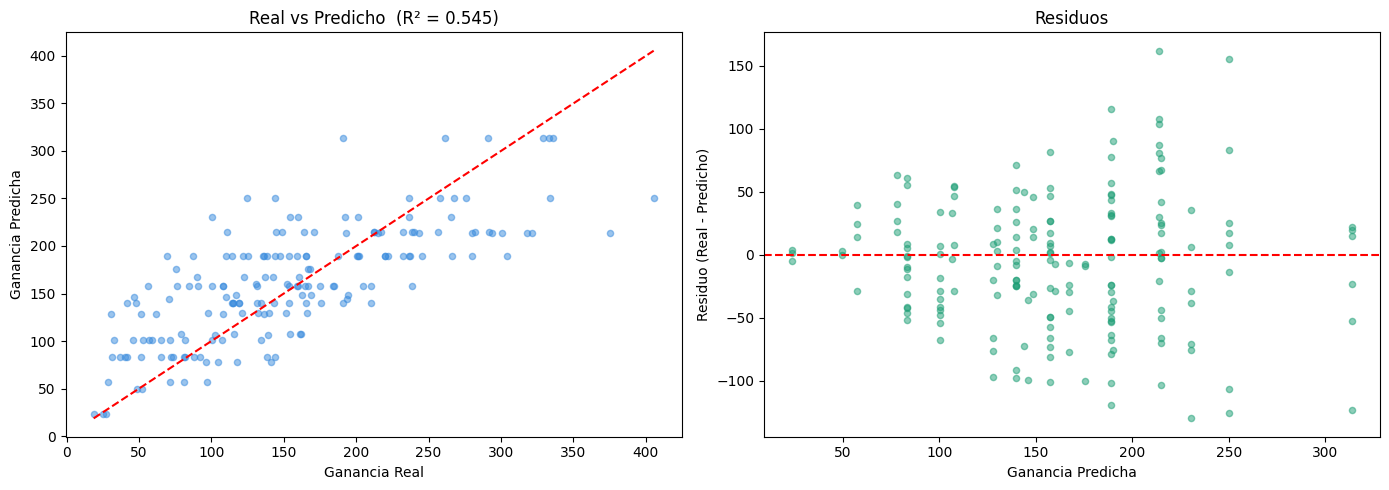

In [ ]:
# ================================================================
# PASO 6 — GRÁFICOS
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, color='#378ADD', s=20)
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_title(f'Real vs Predicho  (R² = {r2:.3f})')
axes[0].set_xlabel('Ganancia Real')
axes[0].set_ylabel('Ganancia Predicha')

residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.5, color='#1D9E75', s=20)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuos')
axes[1].set_xlabel('Ganancia Predicha')
axes[1].set_ylabel('Residuo (Real - Predicho)')

plt.tight_layout()
plt.show()

In [ ]:
# R² en Train (para comparar con Test y CV)
y_pred_train = dt_best.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)

print("\n--- COMPARACIÓN TRAIN vs TEST vs CV ---")
print(f"R² Train: {r2_train:.4f}")
print(f"R² Test:  {r2:.4f}")
print(f"R² CV:    {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
diff = r2_train - r2
print(f"Diferencia Train-Test: {diff:.4f} {'⚠️ posible overfitting' if diff > 0.1 else '✅ OK'}")


--- COMPARACIÓN TRAIN vs TEST vs CV ---
R² Train: 0.6045
R² Test:  0.5452
R² CV:    0.356 ± 0.077
Diferencia Train-Test: 0.0593 ✅ OK


# 3er MODELO RANDOM FOREST

In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [222]:
# ================================================================
# PASO 1 — PREPARAR VARIABLES (mismas que en Decision Tree)
# ================================================================

cols_cat = ['categoria_principal', 'marca_principal',
             'channel', 'country', 'age_range']

le = LabelEncoder()
for col in cols_cat:
    if col in df.columns:
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))

features = [
    'n_productos', 'precio_promedio', 'desc_maximo',
    'categoria_principal_enc','marca_principal_enc', #ACA AGREGAMOS MARCA PRINCIPAL Y USAMOS LA ENCODIFICADA
    'channel_enc', 'country_enc', 'age_range_enc'
]
features = [f for f in features if f in df.columns]

X = df[features]
y = df['ganancia_total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (724, 8) | Test: (181, 8)


In [223]:
# ================================================================
# PASO 2 — MODELO BASE
# ================================================================

rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train_procesado, y_train) # Use preprocessed data for fitting
y_pred_base = rf_base.predict(X_test_procesado) # Use preprocessed data for prediction

print("\n--- RANDOM FOREST BASE ---")
print(f"R²:   {r2_score(y_test, y_pred_base):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_base):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.2f}")


--- RANDOM FOREST BASE ---
R²:   0.5057
MAE:  44.12
RMSE: 55.76


In [224]:
# ================================================================
# PASO 3 — TUNEO
# ================================================================

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, 15, None],
    'min_samples_leaf':  [1, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid.best_params_}")
print(f"Mejor R² en CV:     {grid.best_score_:.4f}")


Mejores parámetros: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 5, 'n_estimators': 300}
Mejor R² en CV:     0.4153


In [225]:
# ================================================================
# PASO 4 — MODELO TUNEADO
# ================================================================

rf_best = grid.best_estimator_
y_pred  = rf_best.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- RANDOM FOREST TUNEADO ---")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Train vs Test vs CV
y_pred_train = rf_best.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
cv_scores = cross_val_score(rf_best, X, y, cv=5, scoring='r2')

print("\n--- TRAIN vs TEST vs CV ---")
print(f"R² Train: {r2_train:.4f}")
print(f"R² Test:  {r2:.4f}")
print(f"R² CV:    {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
diff = r2_train - r2
print(f"Diferencia Train-Test: {diff:.4f} {'⚠️ overfitting' if diff > 0.1 else '✅ OK'}")


--- RANDOM FOREST TUNEADO ---
R²:   0.5138
MAE:  45.15
RMSE: 55.30

--- TRAIN vs TEST vs CV ---
R² Train: 0.5058
R² Test:  0.5138
R² CV:    0.324 ± 0.051
Diferencia Train-Test: -0.0080 ✅ OK


agregue, marca principal, por que mejor el r2 el mae el rmse y el cv.

Pero en los anteriores modelos esa variable no estaba incluida porque traia ruido, bajaba el r2

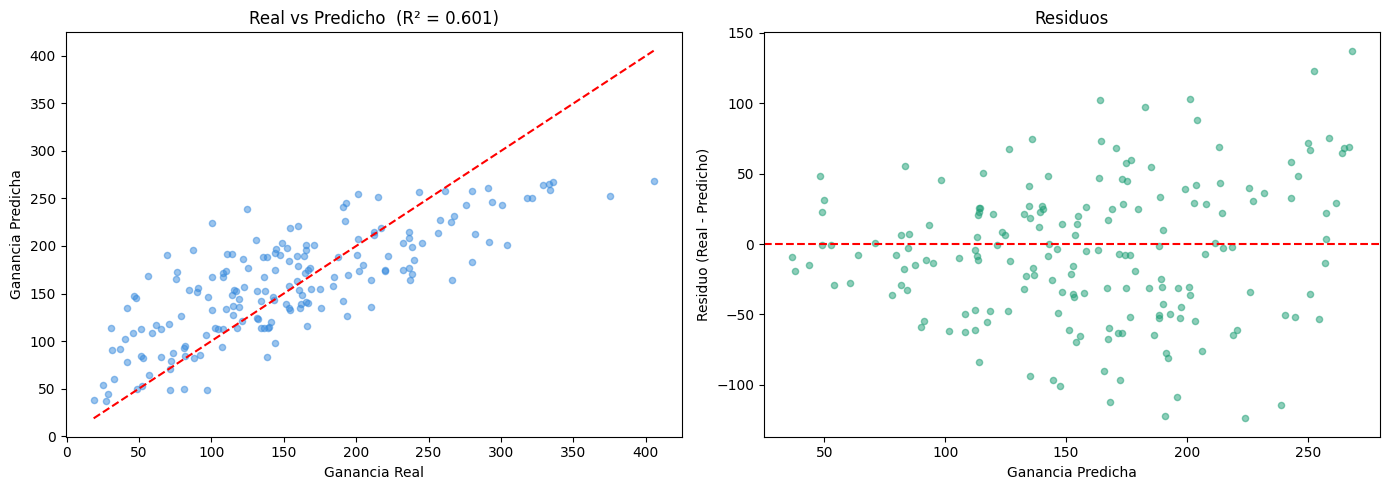

In [ ]:
# ================================================================
# PASO 6 — GRÁFICOS
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, color='#378ADD', s=20)
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_title(f'Real vs Predicho  (R² = {r2:.3f})')
axes[0].set_xlabel('Ganancia Real')
axes[0].set_ylabel('Ganancia Predicha')

residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.5, color='#1D9E75', s=20)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuos')
axes[1].set_xlabel('Ganancia Predicha')
axes[1].set_ylabel('Residuo (Real - Predicho)')

plt.tight_layout()
plt.show()

In [227]:
# ================================================================
# MODELO 4 — XGBOOST
# ================================================================
# pip install xgboost  (si no lo tienes)

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_procesado, y_train)
y_pred_xgb = xgb.predict(X_test_procesado)

r2_xgb   = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
cv_xgb   = cross_val_score(xgb, X_train_procesado, y_train, cv=5, scoring='r2')

print("--- XGBOOST ---")
print(f"R²:   {r2_xgb:.4f}")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"CV R²: {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

--- XGBOOST ---
R²:   0.4861
MAE:  45.29
RMSE: 56.85
CV R²: 0.280 ± 0.042


In [242]:
# ================================================================
# MODELO DE CLASIFICACIÓN — Ganancia Alta / Media / Baja
# ================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# PASO 1 — Crear el target categórico basado en percentiles
def clasificar_ganancia(g):
    if g < 102:
        return 'Baja'
    elif g <= 204:
        return 'Media'
    else:
        return 'Alta'

df_clean['nivel_ganancia'] = df_clean['ganancia_total'].apply(clasificar_ganancia)

print("Distribución de clases:")
print(df_clean['nivel_ganancia'].value_counts())
print(df_clean['nivel_ganancia'].value_counts(normalize=True).round(2))

Distribución de clases:
nivel_ganancia
Media    454
Baja     225
Alta     223
Name: count, dtype: int64
nivel_ganancia
Media    0.50
Baja     0.25
Alta     0.25
Name: proportion, dtype: float64


In [253]:
# PASO 2 — Preparar features (mismas que tenías)
features_num = ['n_productos', 'precio_promedio', 'desc_maximo']
features_cat = ['categoria_principal', 'channel', 'country']

features_num = [f for f in features_num if f in df_clean.columns]
features_cat = [f for f in features_cat if f in df_clean.columns]

X = df_clean[features_num + features_cat]
y = df_clean['nivel_ganancia']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocesador_clf = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), features_cat)
])

X_train_proc = preprocesador_clf.fit_transform(X_train)
X_test_proc  = preprocesador_clf.transform(X_test)

In [254]:
# PASO 3 — Entrenar Regresión Logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

modelo_clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')  #balanceamos las clases, POR Q HAY MAYORES GANANCIAS MEDIAS
modelo_clf.fit(X_train_proc, y_train)

y_pred_clf = modelo_clf.predict(X_test_proc)

print("=== MÉTRICAS CLASIFICACIÓN ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_clf):.4f}")
print()
print(classification_report(y_test, y_pred_clf))

cv_clf = cross_val_score(modelo_clf, X_train_proc, y_train, cv=5, scoring='accuracy')
print(f"CV Accuracy promedio: {cv_clf.mean():.3f} ± {cv_clf.std():.3f}")

=== MÉTRICAS CLASIFICACIÓN ===
Accuracy: 0.5856

              precision    recall  f1-score   support

        Alta       0.60      0.79      0.68        52
        Baja       0.49      0.64      0.55        44
       Media       0.66      0.44      0.52        85

    accuracy                           0.59       181
   macro avg       0.58      0.62      0.59       181
weighted avg       0.60      0.59      0.58       181

CV Accuracy promedio: 0.533 ± 0.040


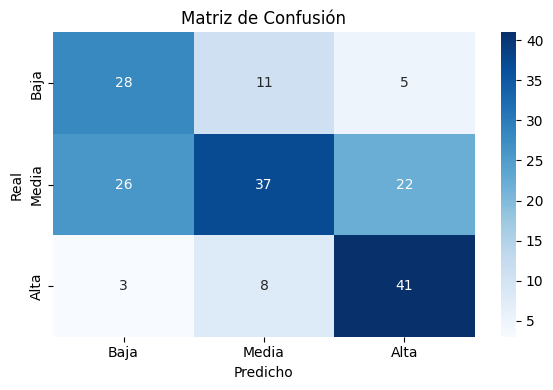

In [250]:
# PASO 4 — Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_clf, labels=['Baja', 'Media', 'Alta'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja', 'Media', 'Alta'],
            yticklabels=['Baja', 'Media', 'Alta'], ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión')
plt.tight_layout()
plt.show()